In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
import numpy as np

In [2]:
pip install tensorflow matplotlib numpy

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.34.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.34.1 which is incompatible.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 1.0/351.2 MB 5.1 MB/s eta 0:01:09
   ---------------------------------------- 1.8/351.2 MB 4.8 MB/s eta 0:01:14
   ---------------------------------------- 3.1/351.2 MB 4.9 MB/s eta 0:01:11
   ---------------------------------------- 3.9/351.2 MB 4.8 MB/s eta 0:01:12
    --------------------------------------- 5.0/351.2 MB 4.8 MB/s eta 0:01:12
    --------------------------------------- 6.3/351.2 MB 5.0 MB/s eta 0:01:09
    --------------------------------------- 7.3/351.2 MB 5.1 MB/s eta 0:01:08
    --------------------------------------- 8.4/351.2 MB 5.0 MB/s eta 0:01:08
   - -------------------------------------- 9.4/351.2 MB 5.0 MB/s eta 0:01:09
   - -------------------------------------- 10.5/351.2 MB 4.9 MB/s eta 0:01:10
   - -------------------------------------- 11.5/351.2 MB 5.0 MB/s eta

In [5]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 1s 35us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


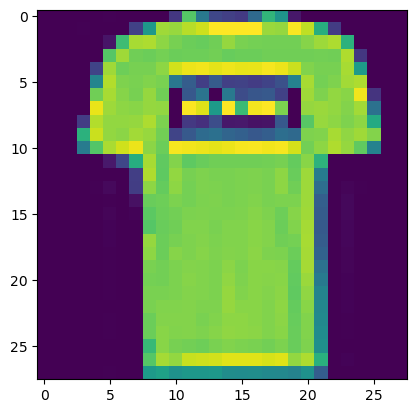

In [6]:
plt.imshow(x_train[1])
plt.show()

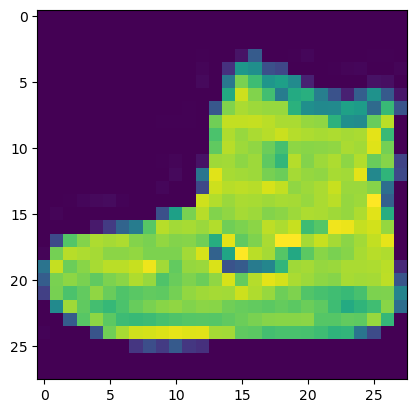

In [7]:
plt.imshow(x_train[0])
plt.show()

In [8]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [9]:
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [10]:
print(x_train.shape)

(60000, 28, 28, 1)


In [11]:
print(x_test.shape)

(10000, 28, 28, 1)


In [12]:
print(y_train.shape)

(60000,)


In [13]:
print(y_test.shape)

(10000,)


In [14]:
model = keras.Sequential([
    
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    
    keras.layers.MaxPooling2D((2,2)),
    
    keras.layers.Dropout(0.25),
    
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    
    keras.layers.MaxPooling2D((2,2)),
    
    keras.layers.Dropout(0.25),
    
    keras.layers.Conv2D(128, (3,3), activation='relu'),
    
    keras.layers.Flatten(),
    
    keras.layers.Dense(128, activation='relu'),
    
    keras.layers.Dropout(0.25),
    
    keras.layers.Dense(10, activation='softmax')
])

C:\Users\91885\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 3, 3, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [19]:
history = model.fit( x_train,y_train,epochs=10,validation_data=(x_test, y_test))


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 14ms/step - accuracy: 0.7944 - loss: 0.5594 - val_accuracy: 0.8396 - val_loss: 0.4186
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - accuracy: 0.8658 - loss: 0.3661 - val_accuracy: 0.8817 - val_loss: 0.3267
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.8826 - loss: 0.3197 - val_accuracy: 0.8953 - val_loss: 0.2884
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.8916 - loss: 0.2945 - val_accuracy: 0.8960 - val_loss: 0.2872
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 14ms/step - accuracy: 0.8971 - loss: 0.2781 - val_accuracy: 0.9046 - val_loss: 0.2662
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 26s 14ms/step - accuracy: 0.9024 - loss: 0.2639 - val_accuracy: 0.9033 - val_loss: 0.2633
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - accuracy: 0.9053 - loss: 0.2530 - val_accuracy: 0.8980 - val_loss: 0.2706
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - accuracy: 0.9077 -

In [20]:
test_loss, test_acc = model.evaluate(x_test, y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9079 - loss: 0.2618


In [21]:
print('Test accuracy:', test_acc)

Test accuracy: 0.9078999757766724
